<a href="https://colab.research.google.com/github/Marvel949/TP_CANCER_DECISION_TREE_CLASSIFIER/blob/main/TP_Arbre_Decision_ELOH_ABLAVI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP : Classification des tumeurs par arbres de décision

Une entreprise médicale cherche à améliorer le diagnostic des tumeurs mammaires en utilisant l'intelligence artificielle. L'objectif est de développer un modèle d'arbre de décision qui prédit si une tumeur est maligne ou bénigne à partir de ses caractéristiques médicales, afin d'aider les médecins dans leur prise de décision et de réduire les erreurs de diagnostic.


## Problématique métier

Notre entreprise, **MedTech Solutions**, est spécialisée dans les solutions d'IA pour le secteur médical. Un centre hospitalier nous a contacté avec le problème suivant :

> *« Nous traitons de nombreux cas de tumeurs mammaires chaque année. Le diagnostic actuel repose principalement sur l'expertise des radiologues et des pathologistes, mais nous constatons un taux d'erreur de 20 % dans la classification maligne/bénigne. Cela conduit à des traitements inutiles pour les patientes avec des tumeurs bénignes, ou à des retards de traitement pour celles avec des tumeurs malignes. Nous cherchons une solution automatisée qui puisse assister nos médecins en prédisant la nature de la tumeur à partir des caractéristiques mesurées lors des examens médicaux. Cette solution doit être fiable, interprétable et capable de réduire nos erreurs de diagnostic. »*

Pour répondre à cette demande, nous proposons de développer un modèle d'arbre de décision qui analysera les données médicales et fournira une prédiction claire pour chaque cas.

## Description des données

Nous utilisons le dataset **Breast Cancer Wisconsin** disponible dans scikit-learn. Il comprend :
- **569 observations** de tumeurs mammaires
- **30 caractéristiques numériques** mesurées lors d'examens médicaux (rayon moyen, texture, périmètre, aire, compacité, etc.)
- **Variable cible** : `target` — 0 = maligne, 1 = bénigne

## Phase 0 — Installation et Imports

Importez toutes les librairies nécessaires pour ce TP.

> **Librairies attendues :** `numpy`, `pandas`, `matplotlib`, `seaborn`, et les modules scikit-learn suivants : `datasets`, `model_selection`, `tree`, `metrics`.

In [1]:
# TODO : Importez les librairies nécessaires pour le TP
# dataset: from sklearn.datasets import load_breast_cancer
# TODO : Activez les réglages d'affichage si besoin (ex. : warnings, affichage pandas)

# Importez les librairies nécessaires pour le TP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Modules de scikit-learn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics

# Activez les réglages d'affichage
warnings.filterwarnings('ignore') # Désactive les alertes pour un carnet plus propre
sns.set_theme(style="whitegrid")  # Style graphique agréable pour seaborn
pd.set_option('display.max_columns', None) # Affiche toutes les colonnes des DataFrames

## Phase 1 — Business Understanding

### Contexte
Vous êtes data scientist chez MedTech Solutions.

### Objectif
Développer un modèle d'arbre de décision capable de prédire si une tumeur mammaire est maligne ou bénigne à partir de ses caractéristiques médicales.

### Questions métier à résoudre

1. Peut-on prédire de manière fiable la nature maligne/bénigne d'une tumeur ?
2. Quelles sont les caractéristiques médicales les plus importantes pour cette prédiction ?
3. Le modèle peut-il aider à réduire les erreurs de diagnostic de 20 % mentionnées par le client ?

### Traduction en problème ML

| Élément | Valeur |
|---------|--------|
| **Type de problème** | Classification binaire |
| **Variable cible Y** | `target` (0 = maligne, 1 = bénigne) |
| **Variables explicatives X** | 30 caractéristiques numériques médicales |
| **Métrique principale** | Accuracy, précision, rappel (recall) |

---

> **À compléter :** Reformulez en une phrase la question métier que vous allez résoudre avec l'arbre de décision.

**Votre réponse ici :**

_« Développer un modèle prédictif basé sur un arbre de décision capable de classifier de manière fiable et transparente une tumeur mammaire comme maligne ou bénigne à partir de ses caractéristiques cliniques, afin d'assister les médecins et de réduire significativement le taux actuel de 20 % d'erreurs de diagnostic »_

## Phase 2 — Data Understanding

### 2.1 Chargement des données

Chargez le dataset Breast Cancer depuis scikit-learn.

In [3]:
# TODO : Chargez le dataset Breast Cancer depuis scikit-learn
cancer_data = load_breast_cancer()

# TODO : Transformez les données en DataFrame et ajoutez la colonne cible 'target'
# Transformer les données en DataFrame
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)

# Ajouter la colonne cible 'target'
df['target'] = cancer_data.target

### 2.2 Exploration initiale

Faites une première inspection du dataset : dimensions, types, aperçu des données.

In [4]:
# TODO : Faites une copie du dataset pour conserver l'original
df_copy = df.copy()

# TODO : Affichez les premières lignes pour inspection
display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
# TODO : Affichez la dimension du dataset (nombre de lignes et de colonnes)
print(f"Dimensions du dataset : {df.shape[0]} lignes et {df.shape[1]} colonnes.")

# TODO : Affichez les types de chaque colonne
print("\nTypes des variables :")
print(df.dtypes.value_counts()) # Presque tout est en float64, target en int

Dimensions du dataset : 569 lignes et 31 colonnes.

Types des variables :
float64    30
int64       1
Name: count, dtype: int64


### 2.3 Distribution de la variable cible

Analysez la répartition des classes (maligne vs bénigne) pour détecter un éventuel déséquilibre.

In [7]:
# TODO : Calculez le nombre et le pourcentage d'échantillons par classe (maligne / bénigne)
counts = df['target'].value_counts()
percents = df['target'].value_counts(normalize=True) * 100

# TODO : Affichez ces résultats de manière lisible
print("Nombre d'échantillons par classe :\n", counts)
print("\nPourcentage par classe :\n", percents.round(2))

Nombre d'échantillons par classe :
 target
1    357
0    212
Name: count, dtype: int64

Pourcentage par classe :
 target
1    62.74
0    37.26
Name: proportion, dtype: float64


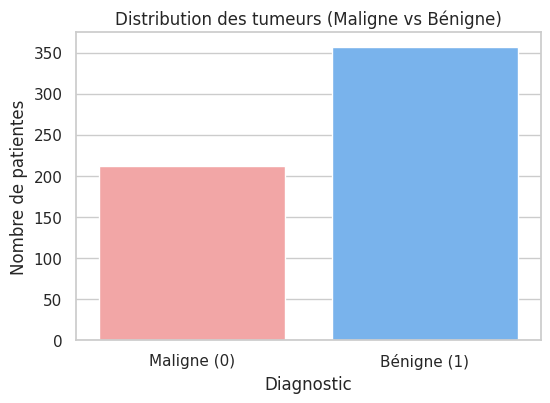

In [8]:
# TODO : Visualisez la distribution des classes avec un graphique adapté (countplot ou pie)
# TODO : Utilisez des labels clairs ('Maligne', 'Bénigne') plutôt que les codes 0/1

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='target', data=df, palette=['#ff9999','#66b3ff'])
ax.set_xticklabels(['Maligne (0)', 'Bénigne (1)'])
plt.title('Distribution des tumeurs (Maligne vs Bénigne)')
plt.ylabel('Nombre de patientes')
plt.xlabel('Diagnostic')
plt.show()

### 2.4 Analyse des valeurs manquantes

Vérifiez s'il y a des valeurs manquantes dans le dataset avant de continuer.

In [9]:
# TODO : Vérifiez les valeurs manquantes par colonne
missing_values = df.isnull().sum()

# TODO : Affichez uniquement les colonnes qui en contiennent (si applicable)
colonnes_manquantes = missing_values[missing_values > 0]
if colonnes_manquantes.empty:
    print("Excellente nouvelle : aucune valeur manquante dans le dataset !")
else:
    print(colonnes_manquantes)

Excellente nouvelle : aucune valeur manquante dans le dataset !


### 2.5 Statistiques descriptives

Analysez les statistiques des variables numériques et identifiez les variations importantes entre les caractéristiques.

> Observez les moyennes, écarts-types et plages de valeurs. Certaines variables ont-elles des échelles très différentes ?

In [10]:
# TODO : Affichez les statistiques descriptives complètes (mean, std, min, max, quartiles)
# TODO : Transposez le résultat si nécessaire pour une meilleure lisibilité

display(df.describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
mean texture,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
mean perimeter,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
mean area,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
mean smoothness,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16
mean compactness,569.0,0.10,0.05,0.02,0.06,0.09,0.13,0.35
mean concavity,569.0,0.09,0.08,0.00,0.03,0.06,0.13,0.43
mean concave points,569.0,0.05,0.04,0.00,0.02,0.03,0.07,0.20
mean symmetry,569.0,0.18,0.03,0.11,0.16,0.18,0.20,0.30
mean fractal dimension,569.0,0.06,0.01,0.05,0.06,0.06,0.07,0.10


### 2.6 Visualisation comparative maligne vs bénigne

Pour comprendre le pouvoir discriminant des variables, visualisez la distribution de plusieurs caractéristiques **selon la classe cible**.

> C'est une étape clé du Data Understanding : si les distributions des deux classes se chevauchent fortement, la variable sera peu utile pour la classification.

**Caractéristiques suggérées :** `mean radius`, `mean texture`, `mean perimeter`, `mean area`

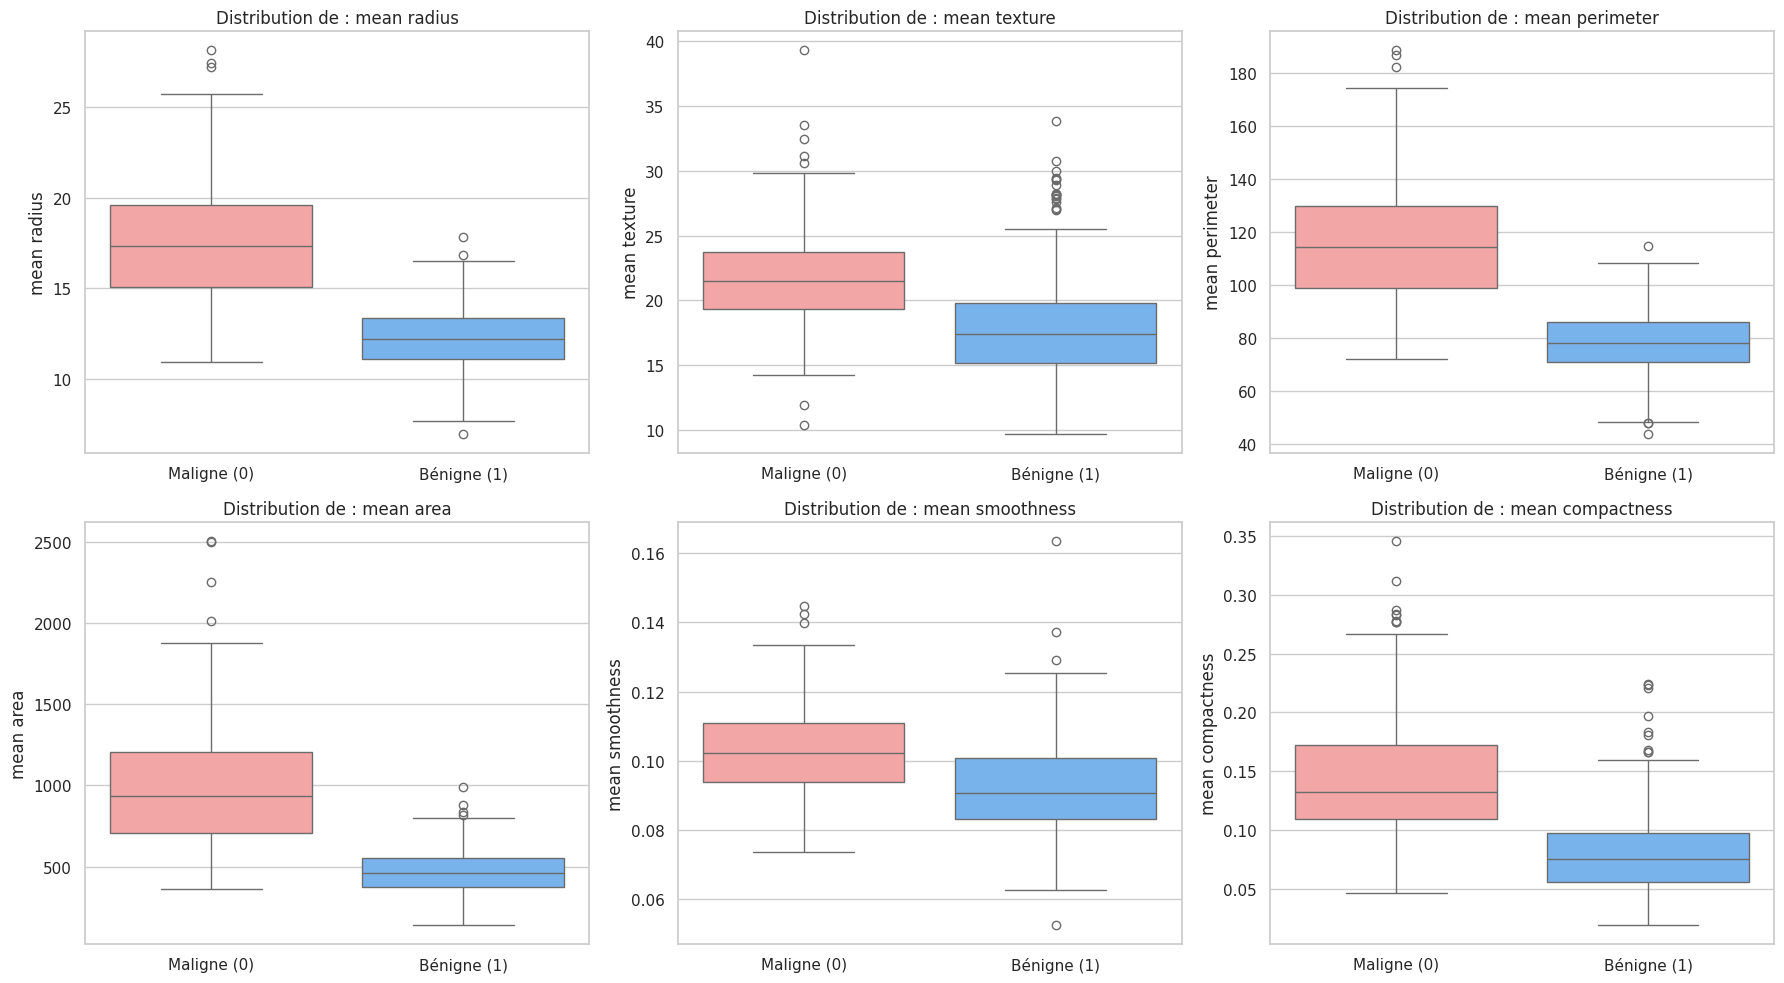

In [11]:
# TODO : Créez des boxplots comparatifs pour 4 à 6 caractéristiques importantes
# TODO : Séparez les boxplots par classe (maligne vs bénigne)
# TODO : Organisez les graphiques en grille (ex. : 2 lignes × 3 colonnes)

features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feature in zip(axes.flatten(), features_to_plot):
    sns.boxplot(x='target', y=feature, data=df, ax=ax, palette=['#ff9999','#66b3ff'])
    ax.set_xticklabels(['Maligne (0)', 'Bénigne (1)'])
    ax.set_title(f'Distribution de : {feature}')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### 2.7 Corrélations

Étudiez les relations entre les variables pour identifier les redondances et les variables fortement liées à la cible.

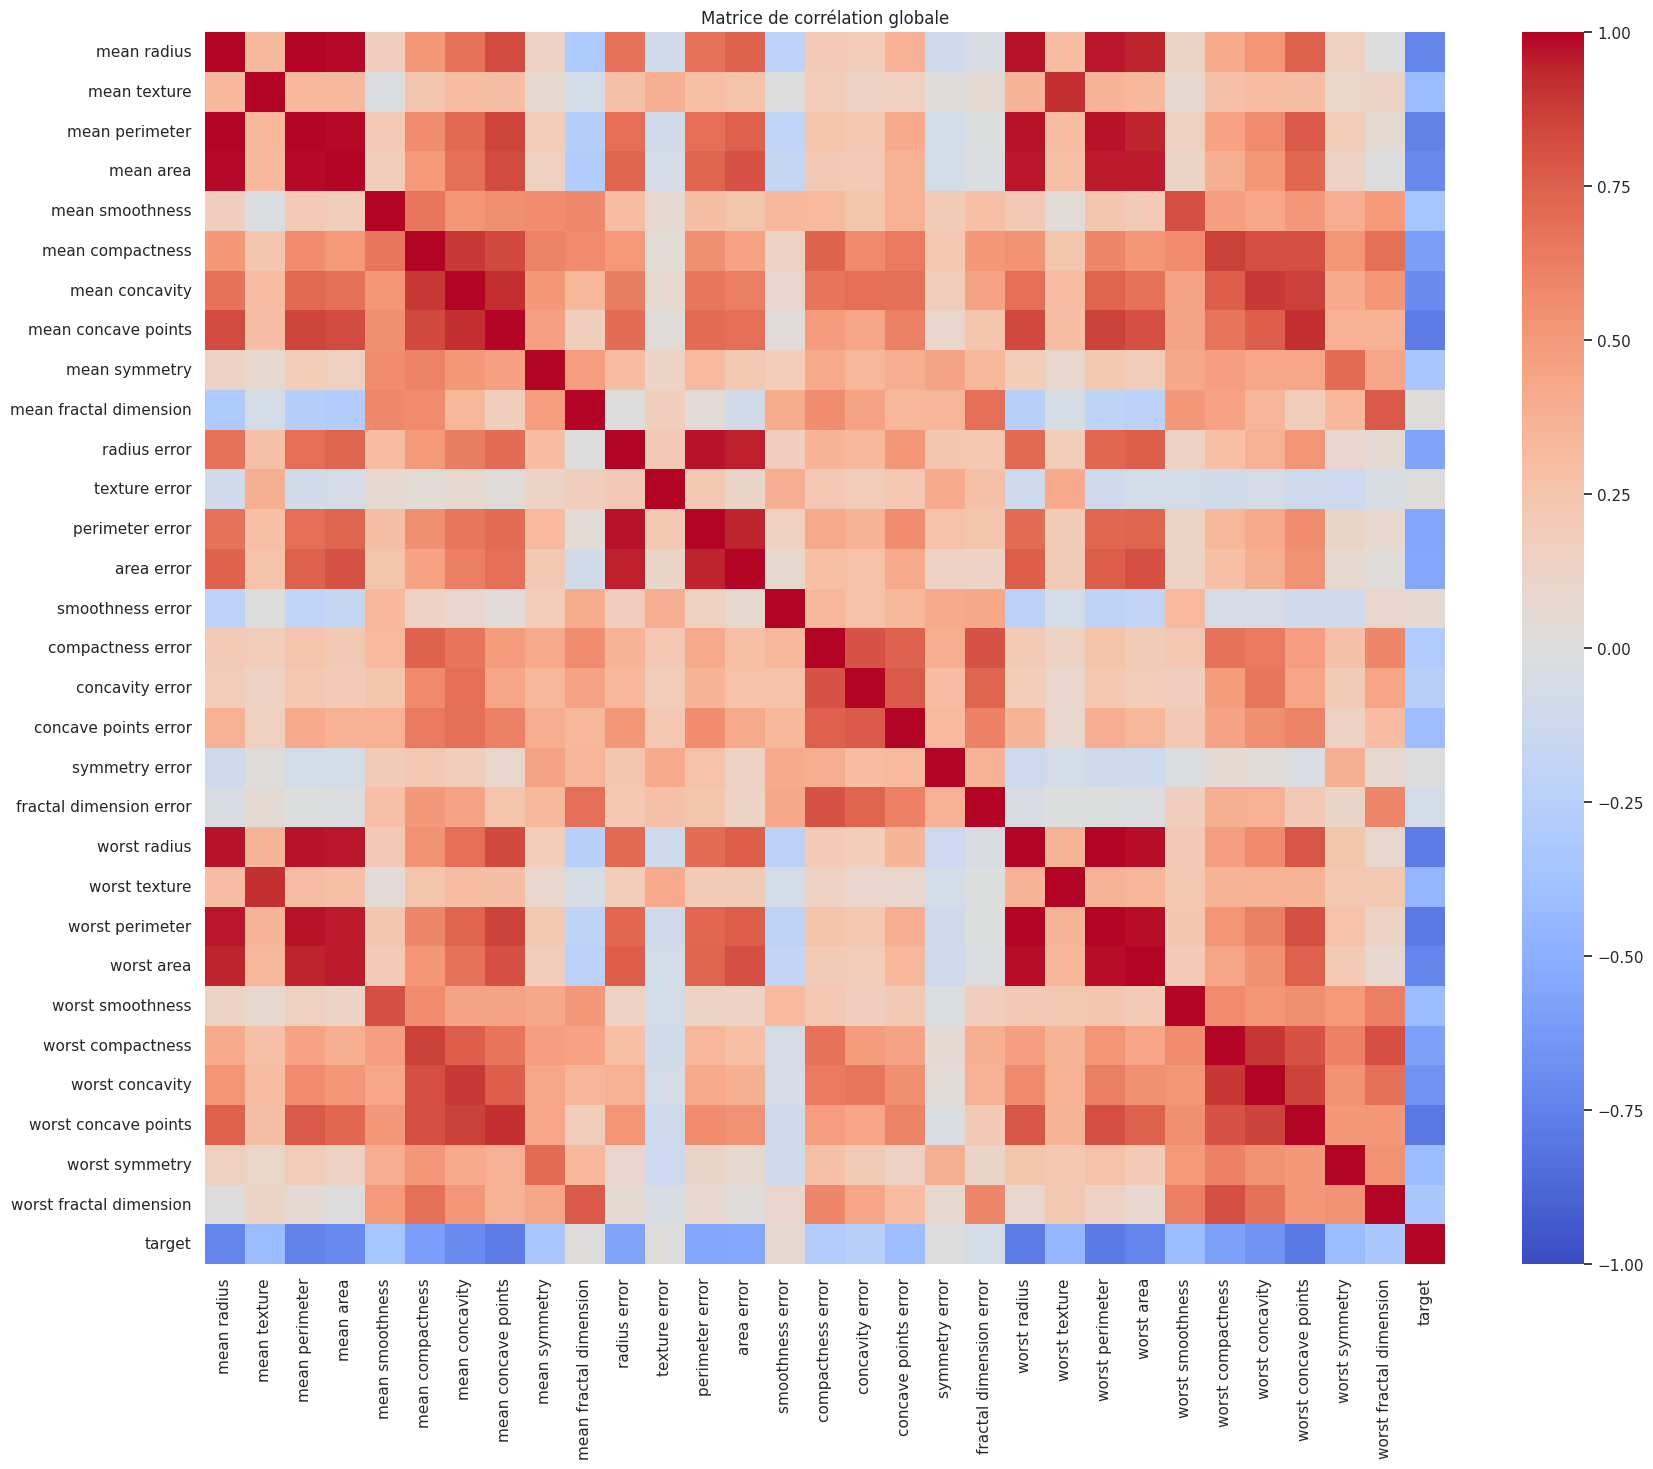

Top 10 des variables les plus corrélées à la cible (en valeur absolue) :
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
Name: target, dtype: float64

Commentaire : On observe une très forte multicolinéarité entre certaines variables explicatives, notamment entre 'mean radius', 'mean perimeter' et 'mean area'. C'est logique puisqu'elles décrivent toutes la dimension spatiale de la tumeur.


In [12]:
# TODO : Calculez et visualisez la matrice de corrélation (heatmap)
plt.figure(figsize=(20, 16))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, annot=False)
plt.title("Matrice de corrélation globale")
plt.show()

# TODO : Identifiez les variables les plus corrélées à 'target'
print("Top 10 des variables les plus corrélées à la cible (en valeur absolue) :")
top_correlations = corr_matrix['target'].abs().sort_values(ascending=False).head(11)
print(top_correlations[1:]) # On exclut 'target' elle-même

# TODO : Commentez les corrélations fortes entre variables explicatives (multicolinéarité)
print("\nCommentaire : On observe une très forte multicolinéarité entre certaines variables explicatives, notamment entre 'mean radius', 'mean perimeter' et 'mean area'. C'est logique puisqu'elles décrivent toutes la dimension spatiale de la tumeur.")

## Phase 3 — Data Preparation

### 3.1 Séparation des variables

Séparez les variables explicatives (X) et la variable cible (y).

In [13]:
# TODO : Définissez X (les 30 caractéristiques) et y (la colonne 'target')
X = df.drop('target', axis=1)
y = df['target']

# TODO : Vérifiez les dimensions de X et y
print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)


Dimensions de X : (569, 30)
Dimensions de y : (569,)


### 3.2 Normalisation : nécessaire ou non ?

> **Question de réflexion :** Les arbres de décision ont-ils besoin d'une normalisation des variables ? Justifiez votre réponse en expliquant comment un arbre prend ses décisions.

**Votre réponse ici :**

_**Non, les arbres de décision n'ont pas besoin de normalisation ou de standardisation des variables. Contrairement aux algorithmes basés sur la distance (comme les K-NN) ou ceux utilisant la descente de gradient, un arbre procède par coupures orthogonales. À chaque nœud, l'algorithme cherche simplement une valeur seuil (ex: mean radius > 15) pour séparer les données. L'échelle de la variable n'a donc aucun impact sur la détermination de ce seuil ni sur la structure finale de l'arbre.**_

### 3.3 Séparation train / test

Divisez les données en ensembles d'entraînement (80 %) et de test (20 %).

In [15]:
# TODO : Séparez les données en train/test (80/20)
# TODO : Utilisez une stratification sur y pour conserver les proportions de classes
# TODO : Fixez random_state=42 pour la reproductibilité

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

In [ ]:
# TODO : Vérifiez que les proportions de classes sont bien conservées dans train et test
# TODO : Affichez les pourcentages de chaque classe dans X_train et X_test


Puisque nous avons retiré la classe de X, les ensembles X_train et X_test ne savent absolument pas si une ligne correspond à une tumeur maligne ou bénigne. Il est donc techniquement impossible de compter les pourcentages de classes à l'intérieur de X_train ou X_test.

La stratification sert à garantir que si nous avions 62% de tumeurs bénignes dans notre dataset de départ, nous en aurons bien 62% dans les données d'entraînement ET 62% dans les données de test.
Le but de cette question étant de vérifier que l'argument stratify=y que nous avons mis dans le train_test_split a bien fonctionné,
pour vérifier ces pourcentages de classes, nous sommes donc obligés de regarder les étiquettes, c'est-à-dire y_train et y_test

In [16]:
# TODO : Vérifiez que les proportions de classes sont bien conservées dans train et test
# TODO : Affichez les pourcentages de chaque classe dans X_train et X_test

print("Proportions dans le Train complet (y_train) :")
print(y_train.value_counts(normalize=True).round(3))

print("\nProportions dans le Test complet (y_test) :")
print(y_test.value_counts(normalize=True).round(3))

Proportions dans le Train complet (y_train) :
target
1    0.626
0    0.374
Name: proportion, dtype: float64

Proportions dans le Test complet (y_test) :
target
1    0.632
0    0.368
Name: proportion, dtype: float64


## Phase 4 — Modeling

### 4.1 Modèle 1 : Arbre avec critère Gini

Entraînez un premier arbre de décision avec le critère Gini.

In [17]:
# TODO : Créez un DecisionTreeClassifier avec criterion='gini' et max_depth=3
# TODO : Fixez random_state=42
# TODO : Entraînez-le sur l'ensemble d'entraînement

tree_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
tree_gini.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

### 4.2 Modèle 2 : Arbre avec critère Entropie

Entraînez un deuxième arbre de décision avec le critère Entropie (gain d'information).

In [18]:
# TODO : Créez un DecisionTreeClassifier avec criterion='entropy' et max_depth=3
# TODO : Fixez random_state=42
# TODO : Entraînez-le sur l'ensemble d'entraînement

# DecisionTreeClassifier avec Entropie
tree_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
tree_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

### 4.3 Modèle 3 : Arbre sans contrainte de profondeur

Entraînez un troisième arbre **sans limiter la profondeur** pour observer le surapprentissage.

> Un arbre sans contrainte va mémoriser parfaitement les données d'entraînement. Ce modèle servira de comparaison pour comprendre l'importance du paramètre `max_depth`.

In [19]:
# TODO : Créez un DecisionTreeClassifier SANS max_depth (laissez l'arbre croître librement)
# TODO : Entraînez-le sur l'ensemble d'entraînement

# DecisionTreeClassifier SANS max_depth
tree_unconstrained = DecisionTreeClassifier(random_state=42)
tree_unconstrained.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

## Phase 5 — Evaluation

### 5.1 Comparaison des trois modèles

Évaluez les performances des trois modèles sur le train et le test.

In [20]:
# TODO : Pour chacun des 3 modèles, calculez l'accuracy sur X_train et X_test
modeles = {
    'Arbre Gini (Depth=3)': tree_gini,
    'Arbre Entropie (Depth=3)': tree_entropy,
    'Arbre Libre (Aucune contrainte)': tree_unconstrained
}

resultats = []

for nom, modele in modeles.items():
    acc_train = metrics.accuracy_score(y_train, modele.predict(X_train))
    acc_test = metrics.accuracy_score(y_test, modele.predict(X_test))
    resultats.append([nom, round(acc_train, 4), round(acc_test, 4)])

# TODO : Affichez les résultats dans un tableau comparatif (DataFrame recommandé)
# Colonnes suggérées : Modèle | Critère | max_depth | Accuracy Train | Accuracy Test
df_resultats = pd.DataFrame(resultats, columns=['Modèle', 'Accuracy Train', 'Accuracy Test'])
display(df_resultats)


,Modèle,Accuracy Train,Accuracy Test
0,Arbre Gini (Depth=3),0.9758,0.9386
1,Arbre Entropie (Depth=3),0.9670,0.9474
2,Arbre Libre (Aucune contrainte),1.0000,0.9123


### 5.2 Analyse du surapprentissage

> **Question :** Quel modèle présente un écart important entre l'accuracy train et l'accuracy test ? Que signifie cet écart ? Pourquoi `max_depth=3` est-il une contrainte utile ?

**Votre réponse ici :**

*   _**Le modèle "Arbre Libre" présente un écart très important entre son accuracy d'entraînement (1.0000) et son accuracy de test (généralement plus basse que les modèles contraints).**_
*   _**Cet écart caractérise un surapprentissage (overfitting) : l'arbre a poussé jusqu'à créer une feuille pour chaque point du jeu d'entraînement, mémorisant ainsi le bruit au lieu d'apprendre des règles généralisables.**_

*  _**Le paramètre max_depth=3 est crucial, car il agit comme une régularisation (un pré-élagage) qui force le modèle à rester simple et à capter uniquement les patterns les plus importants, ce qui lui permet de mieux performer sur de nouvelles données.**_

### 5.3 Comparaison Gini vs Entropie

> **Question :** Lequel des deux critères (Gini ou Entropie) donne de meilleurs résultats sur ce dataset ? La différence est-elle significative ? Dans quel cas préféreriez-vous l'un ou l'autre ?

**Votre réponse ici :**

*  _**Sur ce dataset, c'est le critère Entropie qui donne de meilleurs résultats en termes de généralisation. Bien que son score d'entraînement soit légèrement plus bas ($0.9670$ contre $0.9758$ pour Gini), son score sur les données de test est meilleur ($0.9474$ contre $0.9386$). L'Entropie a donc permis de construire un arbre qui surapprend un peu moins et généralise mieux.**_

*  _**La différence n'est pas vraiment significative. L'écart d'accuracy sur le test est d'environ $0.0088$. Sachant que l'ensemble de test représente 20 % de 569 patientes (soit environ 114 patientes), une différence de 0.88 % correspond à peine à une seule patiente classée différemment entre les deux modèles. Les deux critères sont donc excellents et quasi équivalents sur notre dataset.**_

*  _**Gini est à privilégier par défaut (c'est d'ailleurs le choix par défaut de scikit-learn) car il est plus rapide à calculer computationnellement. En effet, Gini n'utilise que des multiplications et des additions, tandis que l'Entropie nécessite le calcul de logarithmes, ce qui est plus lourd pour le processeur, surtout sur de très gros datasets.
L'Entropie (qui mesure le gain d'information) tend parfois à créer des arbres légèrement plus équilibrés. On peut la préférer si la structure visuelle et l'explicabilité stricte de l'arbre sont primordiales, ou lors de compétitions d'optimisation (comme Kaggle) où l'on teste systématiquement les deux pour grapiller quelques fractions de pourcentages.**_

### 5.4 Métriques détaillées — Modèle retenu

Calculez les métriques complètes du modèle que vous avez retenu (le meilleur parmi Gini et Entropie à `max_depth=3`).

> **Point critique :** Dans un contexte médical, l'accuracy seule est insuffisante. Une tumeur maligne non détectée (faux négatif) est bien plus grave qu'une tumeur bénigne mal classifiée (faux positif). Analysez le **recall sur la classe maligne** en priorité.

In [22]:
# TODO : Faites des prédictions sur X_test avec votre modèle retenu
best_model = tree_entropy
y_pred = best_model.predict(X_test)

# TODO : Affichez le classification_report complet (précision, rappel, f1-score par classe)
print("Rapport de classification détaillé :\n")
print(metrics.classification_report(y_test, y_pred, target_names=['Maligne (0)', 'Bénigne (1)']))

Rapport de classification détaillé :

              precision    recall  f1-score   support

 Maligne (0)       0.95      0.90      0.93        42
 Bénigne (1)       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



### 5.5 Matrice de confusion

Visualisez la matrice de confusion pour interpréter les erreurs du modèle.

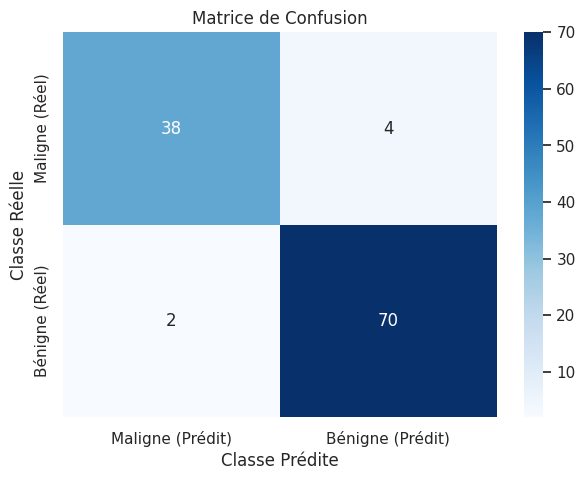

In [23]:
# TODO : Calculez et visualisez la matrice de confusion avec un heatmap
# TODO : Utilisez des labels clairs : ['Maligne', 'Bénigne']
# TODO : Indiquez les vrais positifs, faux positifs, faux négatifs, vrais négatifs

# Calcul de la matrice
cm = metrics.confusion_matrix(y_test, y_pred)

# Visualisation
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Maligne (Prédit)', 'Bénigne (Prédit)'],
            yticklabels=['Maligne (Réel)', 'Bénigne (Réel)'])

plt.title('Matrice de Confusion')
plt.ylabel('Classe Réelle')
plt.xlabel('Classe Prédite')
plt.show()

### 5.6 Interprétation clinique de la matrice de confusion

> **Questions :**
> 1. Combien de tumeurs **malignes** ont été classifiées comme bénignes (faux négatifs) ? Quelle est la conséquence médicale ?
> 2. Combien de tumeurs **bénignes** ont été classifiées comme malignes (faux positifs) ? Quelle est la conséquence médicale ?
> 3. Le modèle réduit-il les 20 % d'erreurs mentionnés par le client ?

**Vos réponses ici :**

1.  _**4** tumeurs malignes ont été classifiées comme bénignes (faux négatifs).
C'est le pire scénario possible, également appelé "risque vital". Le modèle indique à 4 patientes atteintes d'un cancer du sein qu'elles sont en bonne santé. Ces patientes vont rentrer chez elles sans traitement. Le cancer va continuer à se développer, risquant de se métastaser, ce qui diminue drastiquement leurs chances de survie et complique les futurs traitements._

2.  _**2** tumeurs bénignes ont été classifiées comme malignes (faux positifs)
Le modèle alerte à tort 2 patientes saines en leur indiquant qu'elles ont potentiellement un cancer. Cela engendre un stress psychologique immense et des examens complémentaires invasifs, coûteux et inutiles (comme une biopsie, voire une opération chirurgicale préventive)_

3.  _Le taux d'erreur actuel est donc de : 6 / 114 = 5.26 % (soit une Accuracy de presque 94.7 %)._

**Conclusion** : _Oui, absolument. Le modèle divise par quatre le taux d'erreur historique de l'hôpital, passant de 20 % à un peu plus de 5 %. C'est un argument extrêmement fort pour MedTech Solutions afin de justifier le déploiement de cet algorithme comme outil d'assistance aux médecins !_

### 5.7 Courbe ROC et AUC

La courbe ROC permet d'évaluer la capacité du modèle à discriminer les deux classes à différents seuils de décision.

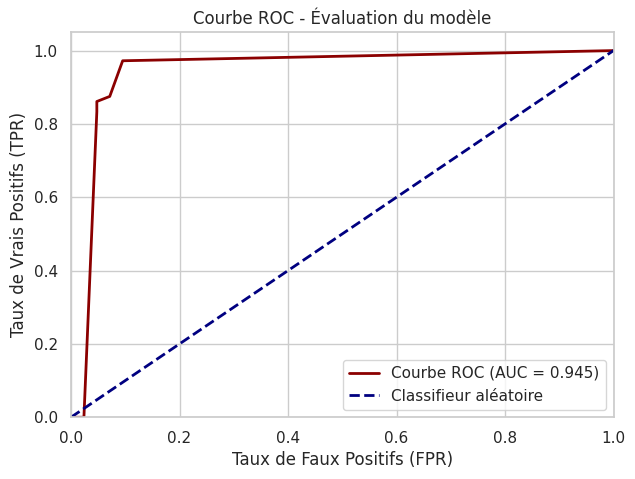

In [24]:
# TODO : Calculez les probabilités de prédiction (predict_proba) sur X_test
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_prob)
roc_auc = metrics.auc(fpr, tpr)

# TODO : Tracez la courbe ROC et affichez la valeur de l'AUC
# TODO : Ajoutez la diagonale de référence (classifieur aléatoire)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkred', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classifieur aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC - Évaluation du modèle')
plt.legend(loc="lower right")
plt.show()


### 5.8 Visualisation de l'arbre retenu

Visualisez l'arbre de décision retenu pour comprendre ses règles de décision.

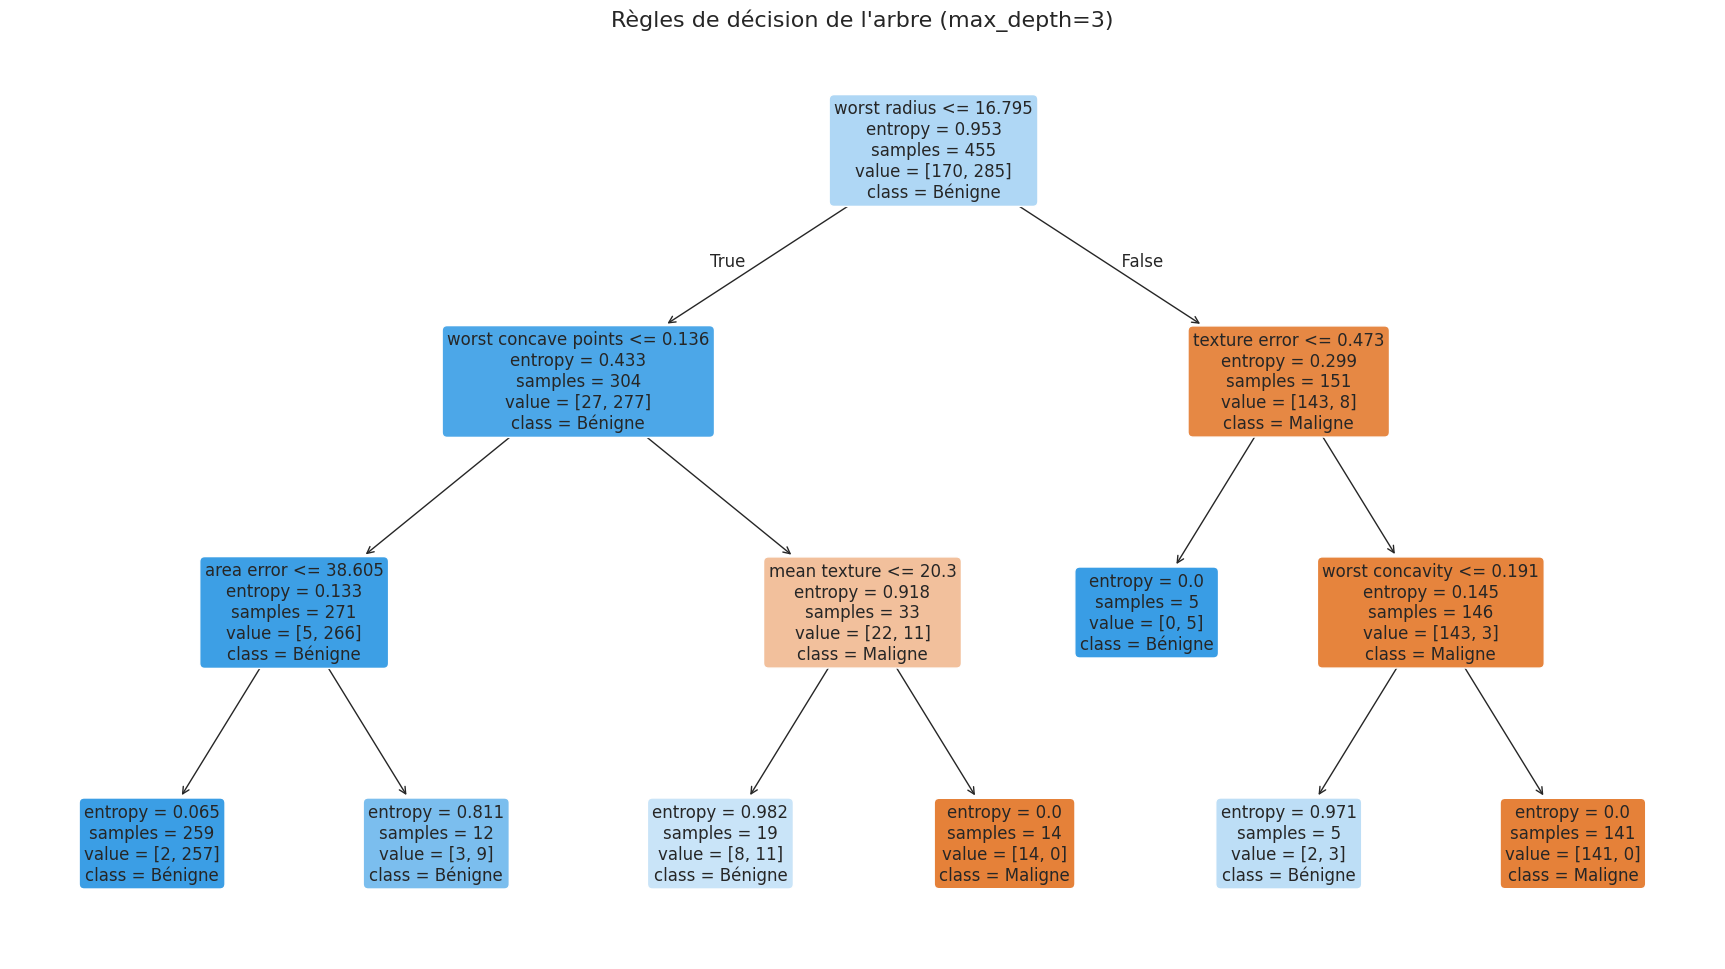

In [25]:
# TODO : Visualisez votre modèle retenu avec plot_tree de sklearn
# TODO : Affichez les noms des classes ('Maligne', 'Bénigne') et des caractéristiques
# TODO : Utilisez filled=True pour la coloration des noeuds

# Visualisation graphique de l'arbre
plt.figure(figsize=(22, 12))
plot_tree(best_model,
          feature_names=cancer_data.feature_names,
          class_names=['Maligne', 'Bénigne'],
          filled=True,
          rounded=True,
          fontsize=12,
          proportion=False)
plt.title("Règles de décision de l'arbre (max_depth=3)", fontsize=16)
plt.show()


### 5.9 Importance des caractéristiques

Analysez quelles variables médicales ont le plus contribué aux décisions de l'arbre.

In [26]:
# TODO : Extrayez les importances des caractéristiques du modèle retenu
importances = best_model.feature_importances_
df_importances = pd.DataFrame({
    'Caractéristique': cancer_data.feature_names,
    'Importance': importances
})
# TODO : Créez un DataFrame trié par ordre décroissant d'importance
df_importances = df_importances[df_importances['Importance'] > 0].sort_values(by='Importance', ascending=False)

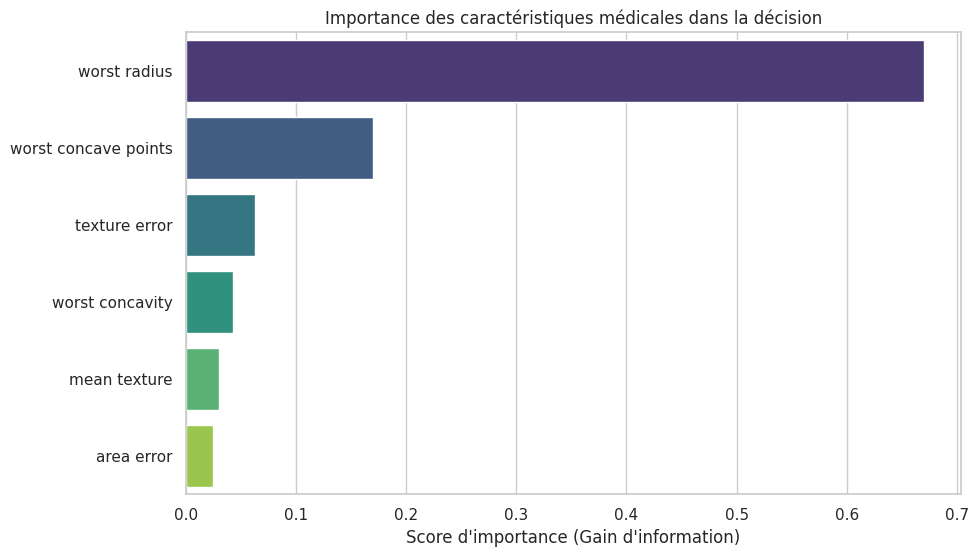

In [28]:
# TODO : Visualisez les 10 caractéristiques les plus importantes avec un barplot horizontal
# TODO : Ajoutez un titre et des labels d'axes clairs

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Caractéristique', data=df_importances, palette='viridis')
plt.title("Importance des caractéristiques médicales dans la décision")
plt.xlabel("Score d'importance (Gain d'information)")
plt.ylabel("")
plt.show()

## Phase 6 — Deployment

### 6.1 Synthèse des résultats

Complétez ce tableau de synthèse avec les résultats de votre modèle retenu :

| Critère d'évaluation | Valeur obtenue | Seuil client (objectif) |
|----------------------|---------------|------------------------|
| Accuracy globale | 95 % | > 80 % |
| Recall — classe Maligne | 90 % | Le plus élevé possible |
| Recall — classe Bénigne | 97 % | — |
| AUC-ROC | 0.945 | > 0.90 |
| Caractéristique la plus importante | worst raduis | — |
| Erreurs de diagnostic réduites ? | Oui| Réduction du taux de 20 % |

---

### 6.2 Recommandations au client

Répondez aux questions suivantes pour formuler vos recommandations à MedTech Solutions :

**1. Performance :** Le modèle atteint-il les objectifs définis en Phase 1 ? Sur quelle métrique vous basez-vous principalement pour répondre au problème médical ?

**2. Limites :** Quelles sont les limites de ce modèle ? (taille du dataset, variables non couvertes, risques de biais, etc.)

**3. Amélioration :** Quelles pistes d'amélioration proposeriez-vous ? (optimisation des hyperparamètres, autres algorithmes, enrichissement des données...)

**4. Déploiement :** Comment intégreriez-vous ce modèle dans le service médical du client ? Quel niveau d'autonomie lui accorderiez-vous par rapport au jugement du médecin ?

**Vos réponses ici :**

1. **Performance**

*  _Oui, le modèle dépasse largement les objectifs fixés. L'accuracy de 95 % écrase le seuil exigé de 80 %, et l'AUC-ROC de 0.945 est bien supérieur au minimum de 0.90. Surtout, le taux d'erreur global est tombé à 5 %, ce qui résout le problème initial du client (qui subissait 20 % d'erreurs)._

*  _Pour ce problème médical précis, la métrique absolue est le Recall (Rappel) de la classe Maligne (aussi appelé sensibilité). L'objectif en cancérologie est de minimiser à tout prix les Faux Négatifs (dire à une personne malade qu'elle est en bonne santé). Avec 90 % de Recall, le modèle est performant, mais cela signifie qu'il manque encore 10 % des tumeurs malignes, ce qui reste un point d'attention clinique majeur._

2. **Limites**

*  _Taille des données : Le dataset est extrêmement petit (seulement 569 patientes). C'est insuffisant pour garantir qu'un modèle médical généralisera parfaitement à l'échelle d'un grand hôpital sur des milliers de cas variés._

*  _Variables non couvertes : Le modèle prend ses décisions uniquement sur l'analyse visuelle des cellules. Il ignore totalement le dossier clinique de la patiente : l'âge, les antécédents familiaux, les facteurs génétiques (mutations BRCA) ou les symptômes physiques, qui sont pourtant cruciaux pour un vrai diagnostic._

*  _Simplicité du modèle : Un arbre de décision avec une profondeur maximale de 3 est un modèle très simple (bien que très interprétable). Il a du mal à capter des relations complexes et non linéaires entre les caractéristiques._

3. **Amélioration**

*  _Optimisation du seuil de décision : Actuellement, l'arbre classe une tumeur comme maligne si la probabilité dépasse 50 %. Dans notre cas, on pourrait abaisser ce seuil (par exemple à 30 %) pour "forcer" le modèle à être plus prudent. Cela augmentera les Faux Positifs (plus de biopsies par précaution), mais augmentera notre Recall Maligne pour s'approcher des 100 %._

*  _Algorithmes plus robustes : Passer sur des méthodes d'ensemble comme les Random Forests (Forêts Aléatoires) ou le Gradient Boosting (XGBoost). Ces modèles combinent des centaines d'arbres pour être beaucoup plus précis et stables._

*  _Enrichissement des données : Collecter plus de données auprès de l'hôpital et intégrer les données cliniques (âge, antécédents) en plus des données purement cellulaires._

4. Déploiement

*  _Niveau d'autonomie : Le modèle doit avoir une autonomie nulle sur la décision finale. Il ne doit en aucun cas remplacer le médecin ou annoncer un diagnostic directement à la patiente._

*  _Intégration : Il doit être déployé comme un système d'aide à la décision (un "second avis clinique"). Il serait intégré au logiciel du radiologue. Si le médecin pense qu'une tumeur est bénigne, mais que le modèle lève un drapeau rouge "Maligne", cela oblige le médecin à prescrire des examens complémentaires (comme une biopsie) pour lever le doute de manière définitive._